In [ ]:
# connecting to the drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing Structured Data - Selena


In [ ]:
# adding path to CSVs

import csv
import pandas as pd
import numpy as np
from datetime import timedelta
import os

!ls '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files'

datapath = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/';

# PARAMETERS
# ---------------------------

N_HOURS = 5          # length of each bin (hours)
N_BINS = 3           # number of temporal bins
AGG_FUN = 'mean'                # aggregation per bin



'2 10 26_all_features_table_09hrs.csv'	 D_LABITEMS.csv
'2 10 26_all_features_table_12hrs.csv'	 DRGCODES.csv
'2 10 26_all_features_table_18hrs.csv'	 ICUSTAYS.csv
 ADMISSIONS.csv				 INPUTEVENTS_CV.csv
 CALLOUT.csv				 INPUTEVENTS_MV.csv
 CAREGIVERS.csv				 LABEVENTS.csv
 CHARTEVENTS.csv			 MICROBIOLOGYEVENTS.csv
 checkpoints				 NOTEEVENTS.csv
 CPTEVENTS.csv				 OUTPUTEVENTS.csv
 DATETIMEEVENTS.csv			 PATIENTS.csv
 D_CPT.csv				 PRESCRIPTIONS.csv
 DIAGNOSES_ICD.csv			 PROCEDUREEVENTS_MV.csv
 D_ICD_DIAGNOSES.csv			 SERVICES.csv
 D_ITEMS.csv


In [ ]:
# create vectors to store hadm-id's we want to use for training

def remove_duplicates(arr):
    """Remove duplicate values from an array while preserving order."""
    seen = set()
    unique = []
    for x in arr:
        if x not in seen:
            unique.append(x)
            seen.add(x)
    return unique


# get list of hadmids from list of subject ids Rachael provided
path = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/train1_small_subject_ids.csv'
subject_ids = pd.read_csv(path).iloc[:, 0].tolist()
#print(subject_ids)

path = f"{datapath}/{'ADMISSIONS.csv'}"
admissions = pd.read_csv(path);
#print(admissions)
training_id = ( admissions.loc[admissions["SUBJECT_ID"].astype(int).isin(subject_ids), "HADM_ID"]
    .unique().tolist())

# training_id = set(training_set.astype("Int64").astype(str))
# print(training_set)
print(len(training_id))
print(len(subject_ids))


# Demo list of training_ids





2856
2418


In [ ]:
# HELPER FUNCTIONS
# ---------------------------

# def load_filtered_csv(filename, usecols=None):
#     """Load CSV, keep only rows with HADM_ID in training_id."""
#     path = f"{datapath}/{filename}"

#     dtype_overrides = {
#         'SUBJECT_ID': 'string',
#         'HADM_ID': 'string',
#         'ICUSTAY_ID': 'string',
#         'ITEMID': 'string',
#         'ROW_ID': 'string',
#         'DOB': 'string'
#     }

#     df = pd.read_csv(path, usecols=usecols, dtype=dtype_overrides)
#     df.columns = df.columns.str.strip().str.upper()
#     if 'HADM_ID' in df.columns:
#         df = df[df['HADM_ID'].isin([str(x) for x in training_id])]
#     return df

# loading it in chunks for lower memory
def load_filtered_csv_stream(
    filename,
    training_id,
    usecols=None,
    chunksize=300_000
):
    """
    Stream CSV in chunks and keep only rows with HADM_ID in training_id.
    """

    path = f"{datapath}/{filename}"

    # Convert once for fast lookup
    training_id_set = set(str(x) for x in training_id)

    dtype_overrides = {
        'SUBJECT_ID': 'string',
        'HADM_ID': 'string',
        'ICUSTAY_ID': 'string',
        'ITEMID': 'string',
        'ROW_ID': 'string',
        'DOB': 'string'
    }

    filtered_chunks = []

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        dtype=dtype_overrides,
        chunksize=chunksize,
        low_memory=False
    ):
        # Normalize column names per chunk
        chunk.columns = chunk.columns.str.strip().str.upper()

        # Filter only if HADM_ID exists
        if 'HADM_ID' in chunk.columns:
            chunk = chunk[chunk['HADM_ID'].isin(training_id_set)]

        if not chunk.empty:
            filtered_chunks.append(chunk)

    if not filtered_chunks:
        return pd.DataFrame(columns=usecols)

    return pd.concat(filtered_chunks, ignore_index=True)


# put things into time bins
def aggregate_in_bins(df, time_col, value_cols, ref_time_col='REF_TIME'):
    """Bin events into N_HOURS windows relative to ref_time_col."""
    results = []

    for hadm, sub in df.groupby('HADM_ID'):
        ref_time = sub[ref_time_col].iloc[0] if ref_time_col in sub else sub[time_col].max()
        ref_time = pd.to_datetime(ref_time)
        sub[time_col] = pd.to_datetime(sub[time_col])

        # Compute time difference (hours) from reference
        sub['delta_h'] = (ref_time - sub[time_col]).dt.total_seconds() / 3600

        # Select only the last N_BINS * N_HOURS window
        sub = sub[sub['delta_h'] >= 0]
        sub = sub[sub['delta_h'] <= N_BINS * N_HOURS]

        # Bin index: 0 (oldest) to N_BINS-1 (most recent)
        sub['bin'] = (sub['delta_h'] // N_HOURS).astype(int)
        sub['bin'] = N_BINS - 1 - sub['bin']  # invert order (bin2 = most recent)

        # Aggregate by bin
        agg = sub.groupby('bin')[value_cols].agg(['mean','min','max','std'])
        agg.columns = ['_'.join([c, stat, f'bin{b}'])
                       for b in agg.index for c in value_cols for stat in ['mean','min','max','std']][:len(agg.columns)]
        agg['HADM_ID'] = hadm
        results.append(agg.reset_index(drop=True))

    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame()


# function to help with saving files while running thru each section

import os, glob

OUTDIR = f"{datapath}/checkpoints"
os.makedirs(OUTDIR, exist_ok=True)

def save_section(df, name):
    path = f"{OUTDIR}/{name}.parquet"   # parquet is faster/smaller than csv
    df.to_parquet(path, index=False)
    print("saved", path)




In [ ]:
# loading in csv files

admissions = load_filtered_csv_stream('ADMISSIONS.csv', training_id, usecols=['SUBJECT_ID','HADM_ID','ADMITTIME','ADMISSION_TYPE','ETHNICITY'])
patients = load_filtered_csv_stream('PATIENTS.csv', training_id, usecols=['SUBJECT_ID','GENDER','DOB'])

print(admissions.columns.tolist())

# for FUTURE:  add randomized times
admissions['ADMITTIME'] = pd.to_datetime(admissions['ADMITTIME'])
patients['DOB'] = pd.to_datetime(patients['DOB'])
merged_static = admissions.merge(patients, on='SUBJECT_ID', how='left')
merged_static['ADMITTIME'] = pd.to_datetime(merged_static['ADMITTIME'], errors='coerce')
merged_static['DOB'] = pd.to_datetime(merged_static['DOB'], errors='coerce')

# Compute age in years
merged_static['AGE'] = ( merged_static["ADMITTIME"].dt.year - merged_static["DOB"].dt.year -
        ((merged_static["ADMITTIME"].dt.month < merged_static["DOB"].dt.month) |
        ((merged_static["ADMITTIME"].dt.month == merged_static["DOB"].dt.month) &
            (merged_static["ADMITTIME"].dt.day < merged_static["DOB"].dt.day)) ).astype(int)
)
#print(merged_static['AGE'])

# Cap maximum age to 90 (MIMIC policy)
# merged_static.loc[merged_static['AGE'] > 90, 'age'] = 90
# static_features_table = merged_static[['HADM_ID','GENDER','ADMISSION_TYPE','ETHNICITY']]
static_features_table = merged_static[['HADM_ID','SUBJECT_ID','AGE','GENDER','ADMISSION_TYPE','ETHNICITY']]

# Columns to encode
categorical_cols = ["GENDER", "ETHNICITY", "ADMISSION_TYPE"]

# Ensure they are hashable (strings)
for col in categorical_cols:
    static_features_table[col] = static_features_table[col].astype(str)

# One-hot encode
static_features_table_encoded = pd.get_dummies(static_features_table, columns=categorical_cols, dtype = int, drop_first=False)

print(static_features_table_encoded)
static_features_table_encoded.to_csv(f"{OUTDIR}/static_features_table.csv", index=False)


['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'ADMISSION_TYPE', 'ETHNICITY']
     HADM_ID SUBJECT_ID  AGE  GENDER_F  GENDER_M  \
0     190539         49   80         0         1   
1     190797         52   38         0         1   
2     138795         54    0         1         0   
3     176332         61   54         0         1   
4     189535         61   55         0         1   
...      ...        ...  ...       ...       ...   
2851  149152      32048    0         0         1   
2852  132900      29722   66         1         0   
2853  122835      29722   66         1         0   
2854  118311      29722   66         1         0   
2855  146840      32491    0         1         0   

      ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE  ETHNICITY_ASIAN  \
0                                           0                0   
1                                           0                0   
2                                           0                0   
3                                        

/tmp/ipython-input-1810428880.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  static_features_table[col] = static_features_table[col].astype(str)
/tmp/ipython-input-1810428880.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  static_features_table[col] = static_features_table[col].astype(str)
/tmp/ipython-input-1810428880.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [ ]:
# creating reference times for each HADM_ID
# ~~ currently just time of latest entry, but will want to randomize in the future

# Ensure datetime conversion
df = load_filtered_csv_stream('CHARTEVENTS.csv', training_id, usecols=['HADM_ID','CHARTTIME'])
hadm_col='HADM_ID'
time_col='CHARTTIME'
#print(df)

df = df.copy()
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
df = df.dropna(subset=[hadm_col, time_col])

# Group and get the latest time per admission
ref_times = (
    df.groupby(hadm_col, as_index=False)[time_col]
      .max()
      .rename(columns={time_col: 'REF_TIME'})
)

print(ref_times)
ref_times.to_csv(f"{OUTDIR}/ref_times.csv", index=False);

     HADM_ID            REF_TIME
0     100031 2140-11-18 14:00:00
1     100132 2179-03-11 08:00:00
2     100192 2127-02-22 07:00:00
3     100290 2116-06-04 10:00:00
4     100388 2159-03-30 10:00:00
...      ...                 ...
2785  199666 2130-07-23 15:00:00
2786  199802 2195-12-29 11:00:00
2787  199807 2168-09-22 12:00:00
2788  199865 2197-03-15 16:00:00
2789  199913 2198-01-06 18:00:00

[2790 rows x 2 columns]


In [ ]:
# finding the hadm-ids of similar items (i.e. "heart rate" and "heart rates")

import re

def find_ITEMIDs_by_LABEL(df, keywords, case_insensitive=True, fuzzy=False):
    """
    Search D_ITEMS or D_LABITEMS for ITEMIDs whose LABEL or ABBREVIATION
    matches one or more given keywords.

    Parameters
    ----------
    dictionary_path : str
        Path to D_ITEMS.csv or D_LABITEMS.csv
    keywords : list of str
        Words/phrases to search for (e.g. ['heart rate', 'pulse'])
    case_insensitive : bool
        If True, match regardless of case.
    fuzzy : bool
        If True, use substring matching with word boundaries (slower but catches variations).

    Returns
    -------
    matches : pd.DataFrame
        Subset of the dictionary with matching ITEMIDs and LABELs
    """

    # Build regex pattern
    flags = re.IGNORECASE if case_insensitive else 0
    if fuzzy:
        pattern = '|'.join([fr'\b{re.escape(k)}\b' for k in keywords])
    else:
        pattern = '|'.join([re.escape(k) for k in keywords])

    # Combine LABEL/abbreviation/description fields if they exist
    text_cols = [c for c in ['LABEL', 'abbreviation', 'CATEGORY', 'param_type', 'fluid', 'specimen','SHORT_TITLE','LONG_TITLE'] if c in df.columns]
    df['search_text'] = df[text_cols].astype(str).agg(' '.join, axis=1)

    # Search
    mask = df['search_text'].str.contains(pattern, flags=flags, regex=True)
    matches = df[mask].copy()

    # Keep key columns
    keep_cols = [c for c in ['ITEMID','LABEL','abbreviation','CATEGORY','fluid','specimen','SHORT_TITLE','LONG_TITLE'] if c in matches.columns]
    matches = matches[keep_cols].drop_duplicates(subset=['ITEMID'])

    # Sort alphabetically for readability
    return matches.sort_values('LABEL').reset_index(drop=True)



In [ ]:

# Time bin data helper functions

# loads in the temporal data sets
# def load_temporal_table(filename, usecols, time_col, value_col, item_col=None, ITEMIDs=None):
def load_temporal_table(df, time_col, value_col, item_col=None, ITEMIDs=None):
    """
    Takes a pre-loaded df and prepares a temporal table (like CHARTEVENTS or LABEVENTS).
    Optionally maps ITEMIDs to meaningful LABELs.
    """
    # path = f"{datapath}/{filename}"
    # df = pd.read_csv(path, usecols=usecols, low_memory=False)
    # df.columns = df.columns.str.strip().str.upper()

     # Filter by HADM_ID
    df = df[df['HADM_ID'].isin(set(map(str, training_id)))]

    # print("rows after HADM filter:", len(df))
    # print("unique ITEMIDs (sample):", df[item_col].unique()[:10])
    # print("ITEMIDs passed in (sample):", list(ITEMIDs)[:10])
    # print("types:", df[item_col].dtype, type(list(ITEMIDs)[0]))

    # Filter by ITEMIDs if provided
    if ITEMIDs is not None:
        # ITEMIDs might be a pandas Series or list; ensure it's a list
        ITEMID_list = list(ITEMIDs)
        df = df[df[item_col].isin(set(map(str, ITEMID_list)))]

    print("df ITEMID sample:", df[item_col].head(20).tolist())
    print("passed ITEMIDs sample:", ITEMID_list[:20])
    print("df unique ITEMIDs sample:", df[item_col].dropna().unique()[:20])

    # Convert to datetime
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.dropna(subset=[time_col, value_col])

    return df


# can split to 3 timebins, find mean, max, min, and change between time bins
# will output NaN value does not exist
def bin_and_average(df, time_col, value_col, hadm_col='HADM_ID', ref_time_col=None, AGG_FUN=('mean','max'), prefix=None, add_trend=True):
    """
    Aggregates a temporal dataframe into N_BINS × BIN_HOURS windows before ref_time_col.
    Returns per-HADM_ID averaged values per bin.
    """
    results = []
    name_prefix = prefix if prefix else value_col

    # Pre-build output column names
    feature_cols = [hadm_col]
    for fun in AGG_FUN:
        for b in range(N_BINS):
            feature_cols.append(f'{name_prefix}_bin{b+1}_{fun}')
        if add_trend and fun == 'mean':
            for b in range(1, N_BINS):
                feature_cols.append(f'change_{name_prefix}_bin{b+1}_{fun}')

    # Empty or invalid DataFrame case
    if df is None or df.empty or not all(c in df.columns for c in [hadm_col, time_col, value_col]):
        print(f"⚠️ No valid data for {name_prefix}, returning NaN-filled feature table.")
        return pd.DataFrame(columns=feature_cols)

    # If ref_time_col not given, use last available time as reference
    if ref_time_col is None:
        df['REF_TIME'] = df.groupby(hadm_col)[time_col].transform('max')
        ref_time_col = 'REF_TIME'

    for hadm, sub in df.groupby(hadm_col):

        # Skip if subset empty or invalid
        if sub.empty or sub[value_col].dropna().empty:
            continue

        ref_time = pd.to_datetime(sub[ref_time_col].iloc[0])
        if pd.isna(ref_time):
            continue

        sub[time_col] = pd.to_datetime(sub[time_col])
        sub = sub.dropna(subset=[time_col, value_col])
        if sub.empty:
            continue

        # Calculate how many hours before reference
        sub['delta_h'] = (ref_time - sub[time_col]).dt.total_seconds() / 3600
        sub = sub[(sub['delta_h'] >= 0) & (sub['delta_h'] <= N_BINS * N_HOURS)]
        if sub.empty:
            # Fill with NaNs for all bins
            row = {hadm_col: hadm}
            name_prefix = prefix if prefix else value_col
            for fun in AGG_FUN:
                for b in range(N_BINS):
                    row[f'{name_prefix}_bin{b+1}_{fun}'] = np.nan
                if add_trend and fun == 'mean':
                    for b in range(1, N_BINS):
                        row[f'change_{name_prefix}_bin{b+1}_{fun}'] = np.nan
            results.append(row)
            continue

        # Compute bin index
        sub['bin'] = np.floor(sub['delta_h'] / N_HOURS).astype(int)
        sub['bin'] = N_BINS - 1 - sub['bin']  # bin2 = most recent

        row = {hadm_col: hadm}
        name_prefix = prefix if prefix else value_col

        # Aggregate per bin
        for fun in AGG_FUN:
            bin_stats = sub.groupby('bin')[value_col].agg(fun)
            for b in range(N_BINS):
                row[f'{prefix}_bin{b+1}_{fun}'] = bin_stats.get(b, np.nan)

            # add trend only for mean
            if add_trend and fun == 'mean':
                for b in range(1, N_BINS):
                    prev = bin_stats.get(b-1, np.nan)
                    curr = bin_stats.get(b, np.nan)
                    delta = curr - prev if pd.notna(curr) and pd.notna(prev) else np.nan
                    row[f'change_{prefix}_bin{b+1}_{fun}'] = delta

        results.append(row)

    # If all groups were empty
    if not results:
        print(f"⚠️ No valid data found for {prefix or value_col}. Returning NaN-filled table.")
        return pd.DataFrame(columns=feature_cols)
    else:
      df_out = pd.DataFrame(results)
      df_out = df_out.groupby('HADM_ID').mean(numeric_only=True).reset_index()
      return df_out



In [ ]:
# generating arrays of ids for vitals
d_items = load_filtered_csv_stream('D_ITEMS.csv', training_id, usecols=['ITEMID','LABEL'])

heart_ids = find_ITEMIDs_by_LABEL(d_items, keywords=['heart rate','atrial rate'], fuzzy=True)
# print(heart_ids)
heart_ids1 = [211,220045];
# print(heart_ids)

sbp_ids = find_ITEMIDs_by_LABEL(d_items, ['blood pressure','systolic'])
# print(sbp_ids)
sbp_ids1 = [6,225309,6701,51,220052,3313,3315,3317,3321,3323,480,482]

dbp_ids = find_ITEMIDs_by_LABEL(d_items, ['blood pressure','diastolic'])
# print(dbp_ids)
dbp_ids1 = [8364,225310,8555,8368,220051,8502,8503,8504,8505,8506,8507,8444,8445,8446]

temp_ids = find_ITEMIDs_by_LABEL(d_items, ['temperature','temp'])
# print(temp_ids)
temp_ids1 = [676,677,223762]

spo2_ids = find_ITEMIDs_by_LABEL(d_items, ['spo2','oxygen saturation'])
# print(spo2_ids)
spo2_ids1 = [228232,646,6719]

MAP_ids = find_ITEMIDs_by_LABEL(d_items, ['map','mean arterial pressure'])
# print(MAP_ids)
MAP_ids1 = [6399, 2309, 2544, 2974, 3067, 6605, 1199, 2522, 6579,438,2369,1321,2770,5804]


# FOR FUTURE - partially manually done, so may not emcompass all the applicable ITEMID's of a larger dataset... need to find a better system


In [ ]:
# loading chart events

chartevents_df = load_filtered_csv_stream('CHARTEVENTS.csv', training_id, usecols=['HADM_ID','CHARTTIME','ITEMID','VALUENUM'])
print(chartevents_df)

chartevents_df.to_csv(f"{OUTDIR}/chartevents_df.csv", index=False)

         HADM_ID  ITEMID            CHARTTIME  VALUENUM
0         110499  220228  2127-01-10 19:59:00       9.0
1         110499  220545  2127-01-10 19:59:00      28.3
2         110499  220546  2127-01-10 19:59:00      14.0
3         110499  220602  2127-01-10 19:59:00     101.0
4         110499  220615  2127-01-10 19:59:00       1.1
...          ...     ...                  ...       ...
20238331  108409  226545  2101-01-14 17:45:00       NaN
20238332  108409  227378  2101-01-14 17:45:00       NaN
20238333  108409  226228  2101-01-16 00:32:00       2.0
20238334  108409  226381  2101-01-16 00:32:00       4.0
20238335  108409  226543  2101-01-16 00:32:00      13.0

[20238336 rows x 4 columns]


In [ ]:
# putting together temporal bins for vitals

heart_ids1 = [211,220045];

# PULSE
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=heart_ids1
)
print(vitals)
# (c) average across all heart-rate-type ITEMIDs per time
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
heart_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="pulse")
#save_section(heart_features, "01_pulse")

print(heart_features.head())


sbp_ids1 = [6,225309,6701,51,220052,3313,3315,3317,3321,3323,480,482]

# SYS BLOOD PRESSURE
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=sbp_ids1
)

# (c) get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
sys_bp_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="sys_bp")

#save_section(sys_bp_features, "02_sysbp")
print(sys_bp_features.head())


dbp_ids1 = [8364,225310,8555,8368,220051,8502,8503,8504,8505,8506,8507,8444,8445,8446]

# DIAS BLOOD PRESSURE
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=dbp_ids1
)

# (c)  get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
dias_bp_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="dias_bp")

#save_section(dias_bp_features, "03_diasbp")
print(dias_bp_features.head())


# MAP
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=MAP_ids1
)

# (c)  get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
print(vitals_grouped)

# (d) bin into temporal windows
MAP_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean','min'), prefix="MAP")

#save_section(MAP_features, "04_MAP")
print(MAP_features.head())


temp_ids1 = [676,677,223762]

# TEMP
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=temp_ids1
)

# (c) get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
temp_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', prefix="temp")

#save_section(temp_features, "05_temp")
print(temp_features.head())


spo2_ids1 = [228232,646,6719]

# SPO2
vitals = load_temporal_table(
    df=chartevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=spo2_ids1
)

# (c) get rid of duplicate entries
vitals_grouped = vitals.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()

# (d) bin into temporal windows
spo2_features = bin_and_average(vitals_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean','min'), prefix="spo2")

#save_section(spo2_features, "06_spo2")
print(spo2_features.head())

df ITEMID sample: ['211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211']
passed ITEMIDs sample: [211, 220045]
df unique ITEMIDs sample: <StringArray>
['211']
Length: 1, dtype: string
         HADM_ID ITEMID           CHARTTIME  VALUENUM
606       143045    211 2167-01-11 04:55:00      98.0
633       143045    211 2167-01-11 05:00:00      82.0
643       109235    211 2108-08-06 13:00:00      82.0
671       143045    211 2167-01-10 16:00:00     122.0
721       143045    211 2167-01-11 15:00:00      97.0
...          ...    ...                 ...       ...
14746685  133757    211 2167-10-21 00:00:00      98.0
14746709  133757    211 2167-10-22 01:00:00     120.0
14746740  133757    211 2167-10-25 21:00:00      56.0
14746787  133757    211 2167-10-26 20:00:00      70.0
14746808  133757    211 2167-10-26 21:00:00      73.0

[513470 rows x 4 columns]
  HADM_ID  pulse_bin1_mean  pulse_bin2_mean  pulse_bin3_

In [ ]:
# combining all vitals feature tables into a single one

import os, glob
from functools import reduce

# # import parquets from drive
# paths = sorted(glob.glob(f"{OUTDIR}/*.parquet"))
# dfs = [pd.read_parquet(p) for p in paths]

# # vitals_features = [heart_features, sys_bp_features, dias_bp_features, MAP_features, temp_features, spo2_features]
# vitals_features = dfs[0];
# for d in dfs[1:]:
#     vitals_features = vitals_features.merge(d, on="HADM_ID", how="left")

# vitals_feature_table = reduce(
#     lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  vitals_features)

# delete parquets after
for path in glob.glob(f"{OUTDIR}/*.parquet"):
    os.remove(path)


# WITHOUT PARQUETS
vitals_features = [heart_features, sys_bp_features, dias_bp_features, MAP_features, temp_features, spo2_features]

vitals_feature_table = reduce(
    lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  vitals_features)

# print(vitals_feature_table)
list(vitals_feature_table.columns)
vitals_feature_table.to_csv(f"{OUTDIR}/vitals_feature_table.csv", index=False)



In [ ]:
# calculating MAP if empty, and if blood pressure is given

# vitals_feature_table1 = vitals_feature_table.copy()

# timebin 1
map_cols = [c for c in vitals_feature_table.columns if "MAP_bin1_mean" in c]
sbp_cols = [c for c in vitals_feature_table.columns if "sys_bp_bin1_mean" in c]
dbp_cols = [c for c in vitals_feature_table.columns if "dias_bp_bin1_mean" in c]

print(map_cols, sbp_cols, dbp_cols)

for map_col, sbp_col, dbp_col in zip(map_cols, sbp_cols, dbp_cols):
    print(map_col, sbp_col, dbp_col)

    mask = vitals_feature_table[map_col].isna() & \
           vitals_feature_table[sbp_col].notna() & \
           vitals_feature_table[dbp_col].notna()

    vitals_feature_table.loc[mask, map_col] = (
        vitals_feature_table.loc[mask, sbp_col] +
        2 * vitals_feature_table.loc[mask, dbp_col]
    ) / 3


# time bin2

map_cols = [c for c in vitals_feature_table.columns if "MAP_bin2_mean" in c]
sbp_cols = [c for c in vitals_feature_table.columns if "sys_bp_bin2_mean" in c]
dbp_cols = [c for c in vitals_feature_table.columns if "dias_bp_bin2_mean" in c]

for map_col, sbp_col, dbp_col in zip(map_cols, sbp_cols, dbp_cols):

    mask = vitals_feature_table[map_col].isna() & \
           vitals_feature_table[sbp_col].notna() & \
           vitals_feature_table[dbp_col].notna()

    vitals_feature_table.loc[mask, map_col] = (
        vitals_feature_table.loc[mask, sbp_col] +
        2 * vitals_feature_table.loc[mask, dbp_col]
    ) / 3


# time bin 3

map_cols = [c for c in vitals_feature_table.columns if "MAP_bin3_mean" in c]
sbp_cols = [c for c in vitals_feature_table.columns if "sys_bp_bin3_mean" in c]
dbp_cols = [c for c in vitals_feature_table.columns if "dias_bp_bin3_mean" in c]

for map_col, sbp_col, dbp_col in zip(map_cols, sbp_cols, dbp_cols):

    mask = vitals_feature_table[map_col].isna() & \
           vitals_feature_table[sbp_col].notna() & \
           vitals_feature_table[dbp_col].notna()

    vitals_feature_table.loc[mask, map_col] = (
        vitals_feature_table.loc[mask, sbp_col] +
        2 * vitals_feature_table.loc[mask, dbp_col]
    ) / 3


# change in MAP

map1_cols = [c for c in vitals_feature_table.columns if "MAP_bin1_mean" in c]
map2_cols = [c for c in vitals_feature_table.columns if "MAP_bin2_mean" in c]
map3_cols = [c for c in vitals_feature_table.columns if "MAP_bin3_mean" in c]

dmap2_cols = [c for c in vitals_feature_table.columns if "change_MAP_bin2_mean" in c]
dmap3_cols = [c for c in vitals_feature_table.columns if "change_MAP_bin3_mean" in c]

for map1_col, map2_col, map3_col, dmap2_col, dmap3_col in zip(map1_cols, map2_cols, map3_cols, dmap2_cols, dmap3_cols):

    # change between time bins 1 and 2
    mask2 = vitals_feature_table[dmap2_col].isna() & \
           vitals_feature_table[map1_col].notna() & \
           vitals_feature_table[map2_col].notna()

    # change between time bins 2 and 3
    mask3 = vitals_feature_table[dmap3_col].isna() & \
           vitals_feature_table[map2_col].notna() & \
           vitals_feature_table[map3_col].notna()

    vitals_feature_table.loc[mask2, dmap2_col] = (
        vitals_feature_table.loc[mask, map2_col] -
        vitals_feature_table.loc[mask, map1_col])

    vitals_feature_table.loc[mask3, dmap3_col] = (
        vitals_feature_table.loc[mask, map3_col] -
        vitals_feature_table.loc[mask, map2_col])


# print(vitals_feature_table['MAP_bin1_mean'])
list(vitals_feature_table.columns)
vitals_feature_table.to_csv(f"{OUTDIR}/vitals_feature_table.csv", index=False)


['MAP_bin1_mean'] ['sys_bp_bin1_mean'] ['dias_bp_bin1_mean']
MAP_bin1_mean sys_bp_bin1_mean dias_bp_bin1_mean


In [ ]:
# finding ITEMIDs for lab

d_lab = load_filtered_csv_stream('D_LABITEMS.csv', training_id, usecols=['ITEMID','LABEL','FLUID','CATEGORY'])

# CREATININE - urine
lab_keywords = ['creatinine']
creatinine_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(creatinine_ids)
creatinine_ids1 = [51067,51080,51081,51006]

# WBC - urine + blood
lab_keywords = ['wbc','white blood']
wbc_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(wbc_ids)
wbc_urine_ids1 = [51516,51517,51518]
wbc_blood_ids1 = [51300]

# LACTATE
lab_keywords = ['lactate']
lactate_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(lactate_ids)
lactate_ids1 = [50813]

# BUN - blood urea nitrogran
lab_keywords = ['nitrogen','urea','bun']
BUN_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(BUN_ids)
BUN_ids1 = [51006]

# AST - aspartate aminotransferase
lab_keywords = ['aspartate','aminotransferase', 'ast']
AST_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(AST_ids)
AST_ids1 = [50878]

# ALT - alanine aminotransferase
ALT_ids1 = [50861]

# BILIRUBIN - urine + blood direct / total
lab_keywords = ['bilirubin']
bilirubin_urine_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(bilirubin_ids)
bilirubin_urine_ids1 = [51464,51465]
bilirubin_dir_ids1 = [50883]
bilirubin_tot_ids1 = [50885]

# GLUCOSE - urine + blood
lab_keywords = ['glucose']
gluc_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(gluc_ids)
gluc_blood_ids1 = [50809,50931,51529]
gluc_urine_ids1 = [51478,51084]

# Na - blood + urine
lab_keywords = ['na','sodium']
Na_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(Na_ids)
Na_blood_ids1 = [50983,50824]
Na_urine_ids1 = [51100]

# K - blood + urine
lab_keywords = ['k','potassium']
pott_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(pott_ids)
pott_blood_ids1 = [50971,50822]
pott_urine_ids1 = [51097]

# BICARBONATE - blood + urine
lab_keywords = ['bicarbonate','bicarb']
bicarb_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(bicarb_ids)
bicarb_blood_ids1 = [50882,50803]
bicarb_urine_ids1 = [51076]

# HEMOGLOBIN
lab_keywords = ['hemoglobin']
hemoglob_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(hemoglob_ids)
hemoglob_ids1 = [50811,51222]

# PLATELETS
lab_keywords = ['platelets']
platelets_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(platelets_ids)
platelets_ids1 = [51240]

# blood pH
lab_keywords = ['pH']
blood_pH_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
# print(blood_pH_ids)
blood_pH_ids1 = [50820]

# blood CO2
lab_keywords = ['pCO2']
blood_pCO2_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(blood_pCO2_ids)
blood_pCO2_ids1 = [50818]

# blood O2
lab_keywords = ['pO2']
blood_pO2_ids = find_ITEMIDs_by_LABEL(d_lab, lab_keywords, fuzzy=True)
#print(blood_pO2_ids)
blood_pO2_ids1 = [50821]


In [ ]:
# loading lab events

labevents_df = load_filtered_csv_stream('LABEVENTS.csv', training_id, usecols=['HADM_ID','ITEMID','CHARTTIME','VALUENUM'])
print(chartevents_df)

labevents_df.to_csv(f"{OUTDIR}/labevents_df.csv", index=False)

         HADM_ID  ITEMID            CHARTTIME  VALUENUM
0         110499  220228  2127-01-10 19:59:00       9.0
1         110499  220545  2127-01-10 19:59:00      28.3
2         110499  220546  2127-01-10 19:59:00      14.0
3         110499  220602  2127-01-10 19:59:00     101.0
4         110499  220615  2127-01-10 19:59:00       1.1
...          ...     ...                  ...       ...
20238331  108409  226545  2101-01-14 17:45:00       NaN
20238332  108409  227378  2101-01-14 17:45:00       NaN
20238333  108409  226228  2101-01-16 00:32:00       2.0
20238334  108409  226381  2101-01-16 00:32:00       4.0
20238335  108409  226543  2101-01-16 00:32:00      13.0

[20238336 rows x 4 columns]


In [ ]:
# turning lab stuff into temporal bins

# WBC urine
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=wbc_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
WBC_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="WBC_urine",)
print(WBC_urine_features.head())

# WBC blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=wbc_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
WBC_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="WBC_blood",)
print(WBC_blood_features.head())

# Lactate
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=lactate_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
lactate_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="lactate",)
print(lactate_features.head())

# Creatinine
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=creatinine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
creatinine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="creatinine",)
print(creatinine_features.head())

# BUN
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=BUN_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
BUN_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="BUN",)
print(BUN_features.head())

# AST
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=AST_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
AST_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="AST",)
print(AST_features.head())

# ALT
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=ALT_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
ALT_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="ALT",)
print(ALT_features.head())

# BILIRUBIN - urine / dir / tot
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bilirubin_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bili_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bili_urine",)
print(bili_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bilirubin_dir_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bili_dir_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bili_dir",)
print(bili_dir_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bilirubin_tot_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bili_tot_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bili_tot",)
print(bili_tot_features.head())

# GLUCOSE - urine / blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=gluc_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
gluc_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="gluc_urine",)
print(gluc_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=gluc_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
gluc_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="gluc_blood",)
print(gluc_blood_features.head())

# Na - urine / blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=Na_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
Na_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="Na_urine",)
print(Na_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=Na_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
Na_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="Na_blood",)
print(Na_blood_features.head())

# K - urine / blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=pott_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
pott_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="pott_urine",)
print(pott_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=pott_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
pott_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="pott_blood",)
print(pott_blood_features.head())

# BICARBONATE - urine/blood
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bicarb_urine_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bicarb_urine_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bicarb_urine",)
print(bicarb_urine_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=bicarb_blood_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
bicarb_blood_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="bicarb_blood",)
print(bicarb_blood_features.head())

# HEMOGLOBIN
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=hemoglob_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
hemoglob_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="hemoglob",)
print(hemoglob_features.head())

# PLATELETS
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=platelets_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
platelets_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="platelets",)
print(platelets_features.head())

# pH, pCO2, pO2
labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=blood_pH_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
blood_pH_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="blood_pH",)
print(blood_pH_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=blood_pCO2_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
blood_pCO2_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="blood_pCO2",)
print(blood_pCO2_features.head())

labs = load_temporal_table(
    df=labevents_df,
    time_col='CHARTTIME',
    value_col='VALUENUM',
    item_col='ITEMID',
    ITEMIDs=blood_pO2_ids1
)
labs_grouped = labs.groupby(['HADM_ID','CHARTTIME'])['VALUENUM'].mean().reset_index()
blood_pO2_features = bin_and_average(labs_grouped, time_col='CHARTTIME', value_col='VALUENUM', AGG_FUN=('mean',), prefix="blood_pO2",)
print(blood_pO2_features.head())


df ITEMID sample: ['51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51516', '51518', '51516', '51516', '51516']
passed ITEMIDs sample: [51516, 51517, 51518]
df unique ITEMIDs sample: <StringArray>
['51516', '51518', '51517']
Length: 3, dtype: string
  HADM_ID  WBC_urine_bin1_mean  WBC_urine_bin2_mean  WBC_urine_bin3_mean  \
0  100132                  NaN                  NaN                  5.0   
1  100388                  NaN                  NaN                  1.0   
2  100439                  NaN                  NaN                  0.0   
3  100489                  NaN                  NaN                  9.0   
4  100728                  NaN                  NaN                  0.0   

   change_WBC_urine_bin2_mean  change_WBC_urine_bin3_mean  
0                         NaN                         NaN  
1                         NaN                         NaN  
2                         

In [ ]:
# combining the lab stuff into 1 feature table

labs_features = [WBC_urine_features,WBC_blood_features,lactate_features,creatinine_features,BUN_features,
                 AST_features,ALT_features,bili_urine_features,bili_dir_features,bili_tot_features,
                 gluc_urine_features,gluc_blood_features,Na_urine_features,Na_blood_features,pott_urine_features,
                 pott_blood_features,bicarb_urine_features,bicarb_blood_features,hemoglob_features,
                 platelets_features,blood_pH_features,blood_pCO2_features,blood_pO2_features,]

labs_feature_table = reduce(
    lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  labs_features)

print(labs_feature_table)
labs_feature_table.to_csv(f"{OUTDIR}/labs_feature_table.csv", index=False)




     HADM_ID  WBC_urine_bin1_mean  WBC_urine_bin2_mean  WBC_urine_bin3_mean  \
0     100031                  NaN                  NaN                  NaN   
1     100132                  NaN                  NaN                  5.0   
2     100192                  NaN                  NaN                  NaN   
3     100290                  NaN                  NaN                  NaN   
4     100388                  NaN                  NaN                  1.0   
...      ...                  ...                  ...                  ...   
2808  199741                  NaN                  NaN                  NaN   
2809  199802                  NaN                  NaN                  NaN   
2810  199807                  NaN                  NaN                  3.0   
2811  199865                  NaN                  NaN                  NaN   
2812  199913                  NaN                  NaN                  NaN   

      change_WBC_urine_bin2_mean  change_WBC_urine_

In [ ]:
# Microbiology IDs
# ~~ no need to do bins ~~

micro = pd.read_csv(
    f"{datapath}/MICROBIOLOGYEVENTS.csv",
    usecols=['HADM_ID','SPEC_TYPE_DESC','ORG_NAME','AB_NAME','INTERPRETATION',],low_memory=False
)
micro = micro[micro['HADM_ID'].isin(training_id)]
micro['INTERPRETATION'] = micro['INTERPRETATION'].str.strip().str.upper()

# Keep valid INTERPRETATIONs (S, I, R) / removing NULLS
micro = micro[micro['INTERPRETATION'].isin(['S', 'I', 'R'])]

# Flag resistant (R) and intermediate (I)
micro['IS_RESISTANT'] = (micro['INTERPRETATION'] == 'R').astype(int)
micro['IS_INTERMEDIATE'] = (micro['INTERPRETATION'] == 'I').astype(int)

# If microorganisms found
culture_presence = (
    micro.groupby('HADM_ID')['ORG_NAME'].nunique().reset_index(name='NUM_ORGANISMS')
)
culture_presence['ANY_POS_CULTURE'] = (culture_presence['NUM_ORGANISMS'] > 0).astype(int)

# Proportion of resistant antibiotics among all tested
resistance_summary = (
    micro.groupby('HADM_ID')['IS_RESISTANT'].mean().reset_index(name='PROP_RESIST')
)

# Count of total antibiotics tested
num_tests = (
    micro.groupby('HADM_ID')['INTERPRETATION'].count().reset_index(name='NUM_ANTIBIOTICS')
)

# Mean proportion of intermediate results
intermediate_summary = (
    micro.groupby('HADM_ID')['IS_INTERMEDIATE'].mean().reset_index(name='PROP_INTERMED')
)

# creating feature table
micro_features_table = (
    culture_presence
    .merge(resistance_summary, on='HADM_ID', how='outer')
    .merge(intermediate_summary, on='HADM_ID', how='outer')
    .merge(num_tests, on='HADM_ID', how='outer')
)

# fill NaNs for patients with no microbiology data
micro_features_table[['NUM_ORGANISMS','ANY_POS_CULTURE','PROP_RESIST','PROP_INTERMED','NUM_ANTIBIOTICS']] = \
    micro_features_table[['NUM_ORGANISMS','ANY_POS_CULTURE','PROP_RESIST','PROP_INTERMED','NUM_ANTIBIOTICS']].fillna(0)

print(micro_features_table)


     HADM_ID  NUM_ORGANISMS  ANY_POS_CULTURE  PROP_RESIST  PROP_INTERMED  \
0     100132              1                1     0.500000       0.000000   
1     100290              1                1     0.000000       0.000000   
2     100419              1                1     0.400000       0.000000   
3     100545              1                1     0.000000       0.000000   
4     100665              1                1     0.285714       0.000000   
..       ...            ...              ...          ...            ...   
639   199516              1                1     0.166667       0.000000   
640   199544              2                1     0.062500       0.000000   
641   199597              1                1     0.000000       0.000000   
642   199646              1                1     0.555556       0.000000   
643   199807              1                1     0.545455       0.227273   

     NUM_ANTIBIOTICS  
0                 20  
1                  2  
2                 

In [ ]:
# helper function for finding overall across 3 time bins

import numpy as np
import pandas as pd

def summarize_over_window(
    df, ref_times,
    hadm_col='HADM_ID', time_col='CHARTTIME', value_col='VALUENUM',
    BIN_HOURS=N_HOURS, N_BIN=N_BINS, AGG_FUN=('mean', 'max'),
    prefix='NONE', fill_missing=True,
    ref_time_col='REF_TIME',  # <-- add this
    debug=True
):

    print(f"hi df rows: {len(df):,}  ref_times rows: {len(ref_times):,}")


    # Normalize column names
    df.columns = df.columns.str.strip().str.upper()
    ref_times.columns = ref_times.columns.str.strip().str.upper()
    hadm_col = hadm_col.upper()
    time_col = time_col.upper()
    value_col = value_col.upper()
    ref_time_col = ref_time_col.upper()

    # Safety checks
    for col in [hadm_col, time_col, value_col]:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in df. Columns: {df.columns.tolist()}")
    for col in [hadm_col, ref_time_col]:
        if col not in ref_times.columns:
            raise KeyError(f"Column '{col}' not found in ref_times. Columns: {ref_times.columns.tolist()}")

    # --- IMPORTANT: align join-key dtype ---
    df[hadm_col] = df[hadm_col].astype("string").str.strip()
    ref_times[hadm_col] = ref_times[hadm_col].astype("string").str.strip()

    # Ensure datetimes
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    ref_times[ref_time_col] = pd.to_datetime(ref_times[ref_time_col], errors='coerce')

    # Optional: numeric values
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

    if debug:
        print(f"[debug] df rows: {len(df):,}  ref_times rows: {len(ref_times):,}")
        print(f"[debug] unique hadm in df: {df[hadm_col].nunique():,}  in ref_times: {ref_times[hadm_col].nunique():,}")
        print(f"[debug] df NaT% {time_col}: {df[time_col].isna().mean():.3f}  ref NaT% {ref_time_col}: {ref_times[ref_time_col].isna().mean():.3f}")
        print(f"[debug] df NaN% {value_col}: {df[value_col].isna().mean():.3f}")

        overlap = set(df[hadm_col].dropna().unique()) & set(ref_times[hadm_col].dropna().unique())
        print(f"[debug] hadm overlap count: {len(overlap):,}")

    # Merge reference times (right keeps all ref_times hadm_ids)
    merged = df.merge(ref_times[[hadm_col, ref_time_col]], on=hadm_col, how='right')

    if debug:
        print(f"[debug] merged rows: {len(merged):,}")
        print(f"[debug] merged NaT% {time_col}: {merged[time_col].isna().mean():.3f}")
        print(f"[debug] merged NaT% {ref_time_col}: {merged[ref_time_col].isna().mean():.3f}")

    # Drop rows with missing timestamps/value before computing delta
    merged = merged.dropna(subset=[ref_time_col, time_col, value_col])

    if debug:
        print(f"[debug] after dropna timestamps+value: {len(merged):,}")

    # Calculate time difference in hours
    merged['delta'] = (merged[ref_time_col] - merged[time_col]).dt.total_seconds() / 3600.0

    # Filter valid time window
    window_hours = BIN_HOURS * N_BIN
    merged = merged[(merged['delta'] >= 0) & (merged['delta'] <= window_hours)]

    if debug:
        print(f"[debug] after window filter (0..{window_hours}h): {len(merged):,}")

    if merged.empty:
        if debug:
            print("⚠️ No matching rows found after window filter.")
        out = ref_times[[hadm_col]].copy()
        for fun in AGG_FUN:
            out[f'{prefix}_{fun}'] = np.nan if not fill_missing else 0
        return out

    # Group and aggregate
    grouped = merged.groupby(hadm_col)[value_col].agg(AGG_FUN).reset_index()
    grouped.columns = [hadm_col] + [f"{prefix}_{f}" for f in AGG_FUN]

    # Include all HADM_IDs (even those without data)
    if fill_missing:
        grouped = ref_times[[hadm_col]].merge(grouped, on=hadm_col, how='left').fillna(0)

    return grouped




In [ ]:
# getting inputevent ITEMIDs that correspond to fluid intake

d_items = pd.read_csv(f"{datapath}/D_ITEMS.csv", low_memory=False)
d_items.columns = d_items.columns.str.strip().str.upper()

# Filter for fluids in inputevents tables
fluids = d_items[
    ((d_items['CATEGORY'] == 'Fluids/Intake') | (d_items['CATEGORY'] == 'Fluids - Other (Not In Use)')) &
    (d_items['LINKSTO'].str.contains('inputevents', case=False, na=False))
].copy()

# Sort and clean
fluids_ids = fluids[['ITEMID', 'LABEL', 'CATEGORY', 'LINKSTO']].sort_values('LABEL')
print(fluids_ids)



       ITEMID                        LABEL                     CATEGORY  \
12069  220861          Albumin (Human) 20%  Fluids - Other (Not In Use)   
12071  220863           Albumin (Human) 4%  Fluids - Other (Not In Use)   
12073  220865                  Aquadestila  Fluids - Other (Not In Use)   
8851   221193             Auto transfusion  Fluids - Other (Not In Use)   
12132  225165             Bicarbonate Base                Fluids/Intake   
...       ...                          ...                          ...   
9300   221009               Vivinox T.E.N.  Fluids - Other (Not In Use)   
9302   221012            Vivonex Pediatric  Fluids - Other (Not In Use)   
9301   221011                 Vivonex Plus  Fluids - Other (Not In Use)   
9303   221013                  Whole Blood  Fluids - Other (Not In Use)   
12256  226362  ZGastric/TF Residual Intake                Fluids/Intake   

              LINKSTO  
12069  inputevents_mv  
12071  inputevents_mv  
12073  inputevents_mv  
885

In [ ]:
# # Making input tables across all time bins

# loading both INPUTEVENTS_MV and INPUTEVENTS_CV - just looking at IV fluid inputs

cols_mv = ['HADM_ID', 'ENDTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM']
input_mv = load_filtered_csv_stream('INPUTEVENTS_MV.csv', training_id, usecols=cols_mv)
  # ENDTIME will be used as CHARTTIME
if 'ENDTIME' in input_mv.columns:
    input_mv.rename(columns={'ENDTIME': 'CHARTTIME'}, inplace=True)
print(input_mv)

cols_cv = ['HADM_ID', 'CHARTTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM']
input_cv = load_filtered_csv_stream('INPUTEVENTS_CV.csv', training_id, usecols=cols_cv)

print(input_cv)


# # Normalize column names
# input_mv.columns = input_mv.columns.str.strip().str.upper()
# input_cv.columns = input_cv.columns.str.strip().str.upper()

# # # Ensure consistent dtypes
# for df in [input_mv, input_cv]:
#     df['HADM_ID'] = pd.to_numeric(df['HADM_ID'], errors='coerce')
#     df['AMOUNT'] = pd.to_numeric(df['AMOUNT'], errors='coerce')
# #    df['CHARTTIME'] = pd.to_datetime(df['CHARTTIME'], errors='coerce')
# #    df.dropna(subset=['HADM_ID', 'CHARTTIME', 'AMOUNT'], inplace=True)
#     df['HADM_ID'] = df['HADM_ID'].astype(int)

# # Combine them
# input_combined = pd.concat([input_mv, input_cv], axis=0, ignore_index=True)
# input_combined_training = input_combined[input_combined['HADM_ID'].isin(training_id)]
# #print(input_combined_training)


#print(fluids_ids)
# input_combined_training = input_combined_training[input_combined_training['ITEMID'].isin(fluids_ids['ITEMID'])]
#print(input_combined_training)

# #print(ref_times)

# input_combined_training.columns = input_combined_training.columns.str.strip().str.upper()
# input_mv = load_filtered_csv_stream('INPUTEVENTS_MV.csv', training_id, usecols=cols_mv)
# ()
# ref_times.columns = ref_times.columns.str.strip().str.upper()
# ref_times['HADM_ID'] = pd.to_numeric(ref_times['HADM_ID'], errors='coerce').astype('Int64')

# print(f"hiii df rows: {input_combined_training.size:,}")
# print(input_combined_training)
# Extract overall timebins feature
input_features_table = summarize_over_window(
    df=input_cv,
    ref_times=ref_times,
    hadm_col='HADM_ID',
    time_col='CHARTTIME',
    value_col='AMOUNT',
    BIN_HOURS=N_HOURS,       # each bin = 2 hr
    N_BIN=N_BINS,          # 3 bins = total 6 hr window
    AGG_FUN=('sum',), # total fluid input volume
    prefix='input',
    fill_missing=True
)
print(input_features_table)
input_features_table.to_csv(f"{OUTDIR}/input_features_table.csv", index=False)


Empty DataFrame
Columns: [HADM_ID, CHARTTIME, ITEMID, AMOUNT, AMOUNTUOM]
Index: []
        HADM_ID            CHARTTIME ITEMID  AMOUNT AMOUNTUOM
0        168383  2120-08-08 08:00:00  30056    30.0        ml
1        168383  2120-08-08 09:00:00  30056    60.0        ml
2        168383  2120-08-08 11:00:00  30056     0.0       NaN
3        132815  2137-10-09 09:30:00  30056    90.0        ml
4        181789  2125-10-26 01:00:00  30056    90.0        ml
...         ...                  ...    ...     ...       ...
1504975  107844  2114-08-10 12:00:00  45990    80.0        ml
1504976  107844  2114-08-10 16:00:00  45990    80.0        ml
1504977  107844  2114-08-10 20:00:00  45990    60.0        ml
1504978  107844  2114-08-10 21:00:00  45990    20.0        ml
1504979  107844  2114-08-11 00:00:00  45990    65.0        ml

[1504980 rows x 5 columns]
hi df rows: 1,504,980  ref_times rows: 2,790
[debug] df rows: 1,504,980  ref_times rows: 2,790
[debug] unique hadm in df: 2,520  in ref_times: 2,

In [ ]:
# Finding output ids for

# OUTPUT
output_keywords = ['urine out']
outputs_ids = find_ITEMIDs_by_LABEL(d_items, output_keywords, fuzzy=True)
print(outputs_ids)
# lactate_ids1 = [50813]



    ITEMID                        LABEL CATEGORY
0    42042              ANGIO URINE OUT      NaN
1    46748           Cath Lab Urine Out      NaN
2    42666               E.R. URINE OUT      NaN
3    44237               E.R. urine out      NaN
4    45415                 ED Urine OUT      NaN
5    44103                 ER urine out      NaN
6    42892                 EW URINE OUT      NaN
7    42765             FARR 6 URINE OUT      NaN
8    43931              Floor urine out      NaN
9    44132          Procedure urine out      NaN
10   43053                    URINE OUT      NaN
11   46177              URINE OUT-ANGIO      NaN
12   40094        Urine Out Condom Cath      NaN
13   40055              Urine Out Foley      NaN
14   40473        Urine Out IleoConduit      NaN
15   40085        Urine Out Incontinent      NaN
16   40056     Urine Out Lt Nephrostomy      NaN
17   40405              Urine Out Other      NaN
18   40057     Urine Out Rt Nephrostomy      NaN
19   40428      Urin

In [ ]:
# loading output values

# outputs = load_temporal_table(
#     filename='OUTPUTEVENTS.csv',
#     usecols=['HADM_ID','CHARTTIME','ITEMID','valueuom'],
#     time_col='CHARTTIME',
#     value_col='VALUE',
#     item_col='ITEMID',
#     ITEMIDs=outputs_ids
# )

# need to find sum across time bin
cols_out = ['HADM_ID', 'ITEMID', 'CHARTTIME', 'VALUE']
outputs = load_filtered_csv_stream('OUTPUTEVENTS.csv', training_id, usecols=cols_out)
# pd.read_csv(
#     f"{datapath}/OUTPUTEVENTS.csv", usecols=cols_out,low_memory=False)

outputs_features_table = summarize_over_window(
    df=outputs,
    ref_times=ref_times,
    hadm_col='HADM_ID',
    time_col='CHARTTIME',
    value_col='VALUE',
    BIN_HOURS=N_HOURS,       # each bin = 2 hr
    N_BIN=N_BINS,          # 3 bins = total 6 hr window
    AGG_FUN=('sum',), # total fluid input volume
    prefix='outputs',
    fill_missing=True
)
print(outputs_features_table)
outputs_features_table.to_csv(f"{OUTDIR}/outputs_features_table.csv", index=False)



hi df rows: 215,978  ref_times rows: 2,790
[debug] df rows: 215,978  ref_times rows: 2,790
[debug] unique hadm in df: 2,375  in ref_times: 2,790
[debug] df NaT% CHARTTIME: 0.000  ref NaT% REF_TIME: 0.000
[debug] df NaN% VALUE: 0.034
[debug] hadm overlap count: 2,375
[debug] merged rows: 216,393
[debug] merged NaT% CHARTTIME: 0.002
[debug] merged NaT% REF_TIME: 0.000
[debug] after dropna timestamps+value: 208,689
[debug] after window filter (0..15h): 20,438
     HADM_ID  outputs_sum
0     100031        385.0
1     100132       2700.0
2     100192          0.0
3     100290       1090.0
4     100388        810.0
...      ...          ...
2785  199666          0.0
2786  199802          0.0
2787  199807        950.0
2788  199865       1730.0
2789  199913          0.0

[2790 rows x 2 columns]


In [ ]:
# COMBINING ALL INTO SINGLE

static_features_table_encoded['HADM_ID'] = pd.to_numeric(static_features_table_encoded['HADM_ID'], errors='coerce').astype('Int64')
vitals_feature_table['HADM_ID'] = pd.to_numeric(vitals_feature_table['HADM_ID'], errors='coerce').astype('Int64')
labs_feature_table['HADM_ID'] = pd.to_numeric(labs_feature_table['HADM_ID'], errors='coerce').astype('Int64')
micro_features_table['HADM_ID'] = pd.to_numeric(micro_features_table['HADM_ID'], errors='coerce').astype('Int64')
input_features_table['HADM_ID'] = pd.to_numeric(input_features_table['HADM_ID'], errors='coerce').astype('Int64')
outputs_features_table['HADM_ID'] = pd.to_numeric(outputs_features_table['HADM_ID'], errors='coerce').astype('Int64')


all_features = [static_features_table_encoded, vitals_feature_table, labs_feature_table, micro_features_table, input_features_table, outputs_features_table]

all_features_table = reduce(
    lambda left, right: pd.merge(left, right, on='HADM_ID', how='outer'),  all_features)

#print(all_features_table)
all_features_table.head()

all_features_table.to_csv(f"{datapath}/all_features_table.csv", index=False)



#Creating Output Files

In [ ]:
import pandas as pd

# --------- Configure your paths ----------
datapath = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/';
diag_path = f"{datapath}/DIAGNOSES_ICD.csv"

# --------- Sepsis ICD-9 definitions ----------
# "Explicit sepsis" style codes (common baseline):
SEPSIS_PREFIXES = ['77181','99591','99592','67020','67022','67024'];
      # septicemia, sepsis, severe sepsis, puerperal sepsis x3

def _normalize_icd9(code: str) -> str:
    """Remove dots/spaces and keep digits/letters."""
    if pd.isna(code):
        return ""
    return str(code).replace(".", "").strip()

def _build_hadm_set(hadm_ids):
    """Ensure hadm_ids is a set of strings for fast membership tests."""
    return set(pd.Series(hadm_ids).astype("string").str.strip().tolist())

def label_sepsis_from_diagnoses_icd(
    hadm_ids,
    diag_file=diag_path,
    use_broad=False,
    chunksize=500_000,
):
    """
    Returns:
      labels: list[int] aligned to hadm_ids (1 if sepsis dx present else 0)
    """

    hadm_set = _build_hadm_set(hadm_ids)

    # Choose code set
    prefixes = SEPSIS_PREFIXES

    # We'll mark positives in a dict keyed by HADM_ID (string)
    sepsis_hadm = set()

    # Stream DIAGNOSES_ICD.csv
    for chunk in pd.read_csv(
        diag_file,
        usecols=["HADM_ID", "ICD9_CODE"],
        dtype={"HADM_ID": "string", "ICD9_CODE": "string"},
        chunksize=chunksize,
    ):
        # restrict to hadm_ids of interest
        chunk["HADM_ID"] = chunk["HADM_ID"].astype("string").str.strip()
        chunk = chunk[chunk["HADM_ID"].isin(hadm_set)]
        if chunk.empty:
            continue

        # normalize ICD9 codes
        icd = chunk["ICD9_CODE"].map(_normalize_icd9)

        # match prefixes
        is_sepsis = False
        # vectorized prefix matching
        mask = pd.Series(False, index=chunk.index)
        for p in prefixes:
            mask |= icd.str.startswith(p)

        # update positives
        sepsis_hadm.update(chunk.loc[mask, "HADM_ID"].tolist())

    # Build label vector aligned to input order
    labels = [1 if str(h).strip() in sepsis_hadm else 0 for h in hadm_ids]
    return labels



In [ ]:
# generating output file for our training set

import pandas as pd

output_path = f"{datapath}/2 10 26_all_features_table_09hrs.csv"

df = pd.read_csv(output_path)
hadm_ids = df["HADM_ID"].tolist()
print(hadm_ids[:10])

y_explicit = label_sepsis_from_diagnoses_icd(hadm_ids, use_broad=False)
print("explicit sepsis labels:", y_explicit)

out = pd.DataFrame({
    "HADM_ID": hadm_ids,
    "SEPSIS_STATUS": y_explicit
})

out.to_csv(f"{datapath}/train1_small_sepsis_labels.csv", index=False)


[100031, 100132, 100192, 100290, 100388, 100419, 100439, 100467, 100489, 100545]
explicit sepsis labels: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 

#Pytorch Neural Network

In [ ]:
# getting PyTorch

!pip3 uninstall -y torchvision torchaudio torch
!pip3 cache purge
!pip3 install torch torchvision torchaudio

Found existing installation: torchvision 0.25.0
Uninstalling torchvision-0.25.0:
  Successfully uninstalled torchvision-0.25.0
Found existing installation: torchaudio 2.10.0
Uninstalling torchaudio-2.10.0:
  Successfully uninstalled torchaudio-2.10.0
Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Files removed: 126
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 147.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 81.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load data

import csv
import pandas as pd
import numpy as np
from datetime import timedelta
import os

!ls '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files'

datapath = '/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/Code/CSV Files/';

file = '2 10 26_all_features_table_18hrs.csv'
path = f"{datapath}/{file}"
features = pd.read_csv(path);

labels = pd.read_csv('/content/drive/MyDrive/25 Fall/BME499 - Senior Capstone/499 Senior Project Group - RaGS/train1_small_sepsis_labels.csv');
ID_COL = "HADM_ID"
LABEL_COL = "SEPSIS_STATUS"




'2 10 26_all_features_table_09hrs.csv'	 D_LABITEMS.csv
'2 10 26_all_features_table_12hrs.csv'	 DRGCODES.csv
'2 10 26_all_features_table_15hrs.csv'	 ICUSTAYS.csv
'2 10 26_all_features_table_18hrs.csv'	 INPUTEVENTS_CV.csv
 ADMISSIONS.csv				 INPUTEVENTS_MV.csv
 CALLOUT.csv				 LABEVENTS.csv
 CAREGIVERS.csv				 MICROBIOLOGYEVENTS.csv
 CHARTEVENTS.csv			 NOTEEVENTS.csv
 checkpoints				 OUTPUTEVENTS.csv
 CPTEVENTS.csv				 PATIENTS.csv
 DATETIMEEVENTS.csv			 PRESCRIPTIONS.csv
 D_CPT.csv				 PROCEDUREEVENTS_MV.csv
 DIAGNOSES_ICD.csv			 SERVICES.csv
 D_ICD_DIAGNOSES.csv			 train1_small_sepsis_labels.csv
 D_ITEMS.csv


In [ ]:
# ----------------------------
# 2) Load + merge
# ----------------------------

# Normalize columns (robust)
features.columns = features.columns.str.strip().str.upper()
labels.columns   = labels.columns.str.strip().str.upper()
ID_COL = ID_COL.upper()
LABEL_COL = LABEL_COL.upper()

# Ensure IDs are strings for safe merge
features[ID_COL] = features[ID_COL].astype("string").str.strip()
labels[ID_COL]   = labels[ID_COL].astype("string").str.strip()

# Merge: keep only admissions that have both features + labels
data = features.merge(labels[[ID_COL, LABEL_COL]], on=ID_COL, how="inner")

print("Merged shape:", data.shape)
print("Label balance:\n", data[LABEL_COL].value_counts(dropna=False))


Merged shape: (2856, 205)
Label balance:
 SEPSIS_STATUS
0    2644
1     212
Name: count, dtype: int64


In [ ]:
# ----------------------------
# 2) Helper Functions (split + preprocessing + metrics)
# ----------------------------
def stratified_train_test_split(y, test_size=0.2, seed=42):
    """Return train_idx, test_idx with stratification on binary y (0/1)."""
    y = np.asarray(y).astype(int)
    rng = np.random.default_rng(seed)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    rng.shuffle(idx0)
    rng.shuffle(idx1)

    n0_test = int(round(len(idx0) * test_size))
    n1_test = int(round(len(idx1) * test_size))

    test_idx = np.concatenate([idx0[:n0_test], idx1[:n1_test]])
    train_idx = np.concatenate([idx0[n0_test:], idx1[n1_test:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return train_idx, test_idx

def impute_median_fit(X):
    """Compute per-feature median ignoring NaNs."""
    med = np.nanmedian(X, axis=0)
    # If a column is all NaN, nanmedian returns NaN -> replace with 0
    med = np.where(np.isnan(med), 0.0, med)
    return med

def impute_median_transform(X, med):
    """Fill NaNs with fitted medians."""
    X2 = X.copy()
    nan_mask = np.isnan(X2)
    if nan_mask.any():
        X2[nan_mask] = np.take(med, np.where(nan_mask)[1])
    return X2

def standardize_fit(X):
    """Compute mean/std per feature; guard std=0."""
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std = np.where(std < 1e-12, 1.0, std)
    return mean, std

def standardize_transform(X, mean, std):
    return (X - mean) / std

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return tp, tn, fp, fn

def precision_recall_f1(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0.0
    acc  = (tp + tn) / max(tp + tn + fp + fn, 1)
    return acc, prec, rec, f1, (tp, tn, fp, fn)

def roc_auc_score_np(y_true, y_score):
    """
    AUROC via rank statistic (Mann–Whitney U). Works for binary labels.
    Returns NaN if only one class present.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    pos = y_true == 1
    neg = y_true == 0
    n_pos = pos.sum()
    n_neg = neg.sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # ranks of scores (average rank for ties)
    order = np.argsort(y_score)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(y_score) + 1)

    # handle ties: average ranks within ties
    sorted_scores = y_score[order]
    i = 0
    while i < len(sorted_scores):
        j = i
        while j + 1 < len(sorted_scores) and sorted_scores[j + 1] == sorted_scores[i]:
            j += 1
        if j > i:
            avg_rank = ranks[order[i:j+1]].mean()
            ranks[order[i:j+1]] = avg_rank
        i = j + 1

    sum_ranks_pos = ranks[pos].sum()
    # U statistic for positives
    U = sum_ranks_pos - n_pos * (n_pos + 1) / 2
    auc = U / (n_pos * n_neg)
    return float(auc)

def average_precision_score_np(y_true, y_score):
    """
    Average Precision (area under PR curve) using the common definition:
    AP = sum_n (P_n * (R_n - R_{n-1})) over thresholds at each positive.
    Returns NaN if no positives.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    n_pos = (y_true == 1).sum()
    if n_pos == 0:
        return float("nan")

    order = np.argsort(-y_score)  # descending
    y_sorted = y_true[order]

    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / n_pos

    # AP: sum precision at each rank where y=1, divided by n_pos
    ap = (precision[y_sorted == 1].sum()) / n_pos
    return float(ap)

In [ ]:
# ----------------------------
# 4) Build X, y
# ----------------------------
feature_cols = [c for c in data.columns if c not in {ID_COL, LABEL_COL}]

# Convert features to numeric; non-numeric -> NaN
X_df = data[feature_cols].apply(pd.to_numeric, errors="coerce")
y = data[LABEL_COL].astype(int).to_numpy()

X = X_df.to_numpy(dtype=np.float32)  # may contain NaN

# ----------------------------
# 5) Split (stratified)
# ----------------------------
train_idx, test_idx = stratified_train_test_split(y, test_size=0.2, seed=42)

X_train_raw, y_train = X[train_idx], y[train_idx]
X_test_raw,  y_test  = X[test_idx],  y[test_idx]

print("Train/Test sizes:", X_train_raw.shape, X_test_raw.shape)

# ----------------------------
# 6) Impute + standardize (fit on train only)
# ----------------------------
med = impute_median_fit(X_train_raw)
X_train = impute_median_transform(X_train_raw, med)
X_test  = impute_median_transform(X_test_raw,  med)

mean, std = standardize_fit(X_train)
X_train = standardize_transform(X_train, mean, std)
print(X_train)
X_test  = standardize_transform(X_test,  mean, std)
print(X_test)

# Torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

Train/Test sizes: (2285, 203) (571, 203)
[[-1.2754748   0.38667488  1.1245606  ... -0.11483592 -0.08413535
   1.5010127 ]
 [ 1.6739424   0.38667488 -0.88924897 ... -0.11483592 -0.3960042
   0.15264156]
 [-1.6283816   0.12895428  1.1245606  ... -0.15472649 -0.34219584
  -0.8565431 ]
 ...
 [-1.0299793   0.04304742 -0.88924897 ... -0.7929758  -0.38212386
  -0.3992694 ]
 [ 0.15038942  0.16331702 -0.88924897 ... -0.11483592 -0.27301368
   0.50690305]
 [-1.3196894  -0.90192807  1.1245606  ... -0.11483592 -0.42784998
  -0.8565431 ]]
[[-0.17010882  0.36949348 -0.88924897 ...  1.121772   -0.4528507
  -0.8565431 ]
 [ 0.90400594  0.24922389  1.1245606  ...  0.7228663  -0.02460792
   2.267323  ]
 [-0.21849029  0.35231212  1.1245606  ... -0.11483592 -0.45310697
  -0.6555437 ]
 ...
 [ 1.049729    0.4897631  -0.88924897 ... -0.11483592 -0.46848077
   0.33354107]
 [-0.53922004 -0.5411192   1.1245606  ... -0.11483592 -0.24226604
   1.8276368 ]
 [ 0.74427766  0.24922389 -0.88924897 ... -0.11483592 -0.15

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 7) Dataset/DataLoader
# ----------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train_t, y_train_t)
test_ds  = TabularDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)


In [ ]:
# ----------------------------
# 8) Model
# ----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(128, 64), dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(in_dim=X_train_t.shape[1]).to(device)

# Class imbalance handling: pos_weight = Nneg/Npos
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [ ]:
# ----------------------------
# 9) Train + evaluate
# ----------------------------
def eval_model(model, loader):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb).cpu().numpy().reshape(-1)
            all_logits.append(logits)
            all_y.append(yb.cpu().numpy().reshape(-1))
    logits = np.concatenate(all_logits)
    ytrue  = np.concatenate(all_y).astype(int)
    probs  = sigmoid(logits)
    preds  = (probs >= 0.5).astype(int)
    return ytrue, probs, preds

def train(model, epochs=25):
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)

        train_loss = running / len(train_ds)

        ytrue, probs, preds = eval_model(model, test_loader)
        acc, prec, rec, f1, (tp, tn, fp, fn) = precision_recall_f1(ytrue, preds)
        auroc = roc_auc_score_np(ytrue, probs)
        auprc = average_precision_score_np(ytrue, probs)

        print(
            f"Epoch {ep:02d} | train_loss={train_loss:.4f} | "
            f"acc={acc:.3f} prec={prec:.3f} rec={rec:.3f} f1={f1:.3f} | "
            f"AUROC={auroc:.3f} AUPRC={auprc:.3f} | "
            f"TP={tp} TN={tn} FP={fp} FN={fn}"
        )

train(model, epochs=25)

Epoch 01 | train_loss=1.2340 | acc=0.625 prec=0.142 rec=0.810 f1=0.241 | AUROC=0.776 AUPRC=0.238 | TP=34 TN=323 FP=206 FN=8
Epoch 02 | train_loss=1.0765 | acc=0.804 prec=0.188 rec=0.500 f1=0.273 | AUROC=0.729 AUPRC=0.253 | TP=21 TN=438 FP=91 FN=21
Epoch 03 | train_loss=0.9115 | acc=0.802 prec=0.202 rec=0.571 f1=0.298 | AUROC=0.739 AUPRC=0.218 | TP=24 TN=434 FP=95 FN=18
Epoch 04 | train_loss=0.7998 | acc=0.764 prec=0.150 rec=0.476 f1=0.229 | AUROC=0.733 AUPRC=0.234 | TP=20 TN=416 FP=113 FN=22
Epoch 05 | train_loss=0.6849 | acc=0.807 prec=0.196 rec=0.524 f1=0.286 | AUROC=0.740 AUPRC=0.247 | TP=22 TN=439 FP=90 FN=20
Epoch 06 | train_loss=0.6192 | acc=0.792 prec=0.171 rec=0.476 f1=0.252 | AUROC=0.711 AUPRC=0.211 | TP=20 TN=432 FP=97 FN=22
Epoch 07 | train_loss=0.5608 | acc=0.811 prec=0.200 rec=0.524 f1=0.289 | AUROC=0.712 AUPRC=0.209 | TP=22 TN=441 FP=88 FN=20
Epoch 08 | train_loss=0.4915 | acc=0.814 prec=0.204 rec=0.524 f1=0.293 | AUROC=0.705 AUPRC=0.206 | TP=22 TN=443 FP=86 FN=20
Epoch 0

In [ ]:
# ----------------------------
# 10) Final metrics + save artifacts
# ----------------------------
ytrue, probs, preds = eval_model(model, test_loader)
acc, prec, rec, f1, (tp, tn, fp, fn) = precision_recall_f1(ytrue, preds)
auroc = roc_auc_score_np(ytrue, probs)
auprc = average_precision_score_np(ytrue, probs)

print("\nFINAL")
print(f"Accuracy={acc:.3f} Precision={prec:.3f} Recall={rec:.3f} F1={f1:.3f}")
print(f"AUROC={auroc:.3f} AUPRC={auprc:.3f}")
print(f"Confusion: TP={tp} TN={tn} FP={fp} FN={fn}")

# Save model + preprocessing stats so you can score new CSVs later
# currently saving to colab session, switch to GoogleDrive later...
torch.save(model.state_dict(), "/content/sepsis_mlp.pt")
np.savez("/content/preprocess_stats.npz", median=med, mean=mean, std=std, feature_cols=np.array(feature_cols))
print("Saved: /content/sepsis_mlp.pt and /content/preprocess_stats.npz")



FINAL
Accuracy=0.863 Precision=0.210 Recall=0.310 F1=0.250
AUROC=0.712 AUPRC=0.201
Confusion: TP=13 TN=480 FP=49 FN=29
Saved: /content/sepsis_mlp.pt and /content/preprocess_stats.npz


/tmp/ipython-input-346211882.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auroc = np.trapz(tpr, fpr)


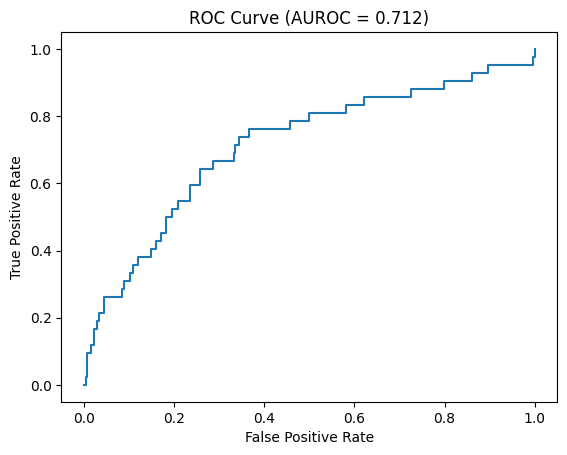

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()

with torch.no_grad():
    logits = model(X_test_t.to(next(model.parameters()).device)).cpu().numpy().reshape(-1)

ytrue = y_test_t.cpu().numpy().reshape(-1)
probs = 1 / (1 + np.exp(-logits))   # sigmoid

# ---- Compute ROC manually ----
order = np.argsort(-probs)
y_sorted = ytrue[order]

tp = np.cumsum(y_sorted == 1)
fp = np.cumsum(y_sorted == 0)

n_pos = (ytrue == 1).sum()
n_neg = (ytrue == 0).sum()

tpr = tp / n_pos
fpr = fp / n_neg

tpr = np.concatenate([[0], tpr])
fpr = np.concatenate([[0], fpr])

auroc = np.trapz(tpr, fpr)

# ---- Plot (no colors specified per rules) ----
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUROC = {auroc:.3f})")
plt.show()

# GC's NN training


In this Section, GC is using Pytorch to try different neural networks that could be part of the project
